<a href="https://colab.research.google.com/github/JazVargasKS20/EstadisticaVerano2026/blob/main/Paractica02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [ ]:
import pandas as pd
#esto es para cargar datos
df = pd.DataFrame({
    "Ausencias": [18,17,29,36,11,28,35,14,20,32,39,16,31,40],
    "Categoría de salario":[11,10,8,5,9,7,3,11,8,7,2,9,8,3]
})

df

,Ausencias,Categoría de salario
0,18,11
1,17,10
2,29,8
3,36,5
4,11,9
5,28,7
6,35,3
7,14,11
8,20,8
9,32,7


1.  *Establesca una variable dependiente ($Y$) y una variable independiente ($X$).*

+ $Y$: es el salario porque este depende de la cantidad de ausencias en cierto periodo.
+ $X$: son las ausencias porque no afectan en nada ya que son dependientes a cada persona o situación.


In [ ]:
# Y: salario
# X: ausencias
X = df['Ausencias']
Y= df['Categoría de salario']

*2.Realize un diagrama de dispercion para estos datodatos.*

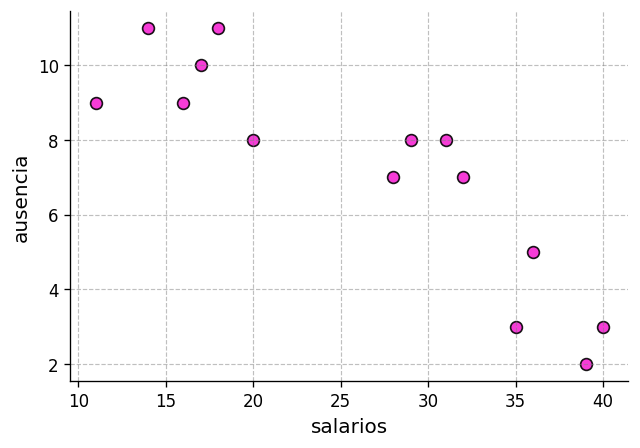

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'salarios', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'ausencia', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

*3.¿los datos soportan la suspencion de linelinealidadlinelinealidad?*


Si porque los datos se muestran en forma paralela respecto a la forma diagonal de la línea.

*4.calcule el coeficiente de coerroelacion e interprete el resultado*

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')


Coeficiente de correlación: -0.8801
valor_p:  0.0000


El coeficiente de correlación es $r=-0.8801$, este valor indica que la correlación es fuerte, dado que está muy cerca de 1. Además, el que sea negativa, implica que aumentar las ausencias ($X$) disminuye el salario ($Y$).

*5.Calcule el coeficiente de determinacion e interprete el resultado*

In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant (X)
modelo = sm.OLS (Y,x_constante).fit ()
y_calculada = modelo.predict (x_constante )

modelo.params

,0
const,14.058843
Ausencias,-0.261814


In [ ]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  77.46%


Con coeficiente de determinación de $$r^2=0.7746$$ indica que con las ausencias estoy justificando en un $77.46\%$ la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

6. **Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión**

In [ ]:
modelo.params

,0
const,14.058843
Ausencias,-0.261814


La ecuación de la recta es:

$$
\hat{y}=14.058843-0.261814X
$$

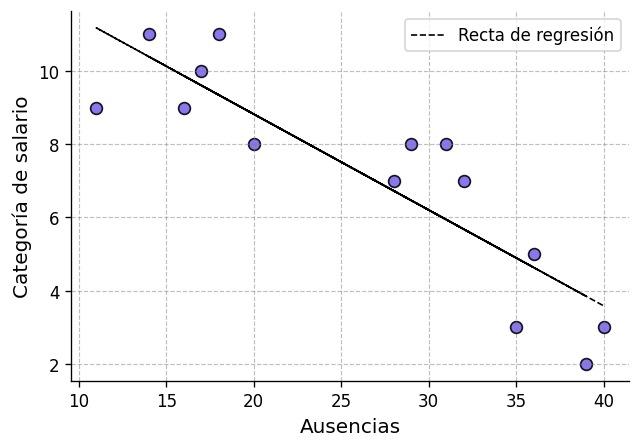

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='MediumSlateBlue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Categoría de salario', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$



In [ ]:
modelo.conf_int(alpha=0.05)

,0,1
const,11.587445,16.530241
Ausencias,-0.350638,-0.172989


El verdadero $b_0$ está entre $11.587445$ y $16.530241$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $-0.350638$ y $-0.172989$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

8. **Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?**

In [ ]:
residuales = modelo.resid

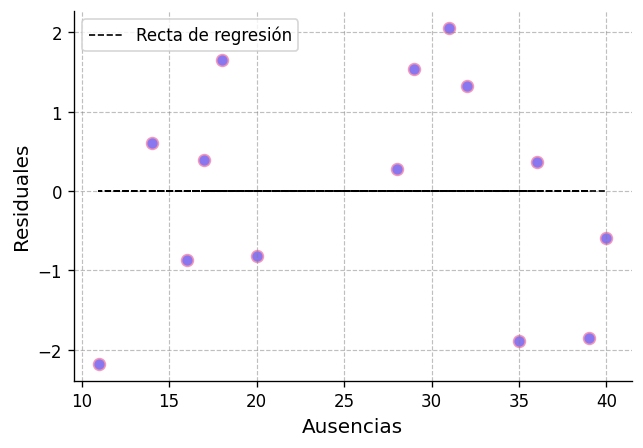

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='MediumSlateBlue',     # color de los puntos
    edgecolor='#F792B4',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que sí, porque van sobre la recta, pero pued ser confuso por la cantidad de datos.
+ Normalidad: Sí cumple con la normalidad, porque hay puntos cerca de la línea.
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque los puntos estan dispersos.
+ Independencia: Sí cumple, porque son diferentes unidades.

9.**RealizaRealizar la prueprueba de shapiro para los residuales para los residuales y comenten los residuales**

valor-p (Shapiro) = 0.4172971767713699


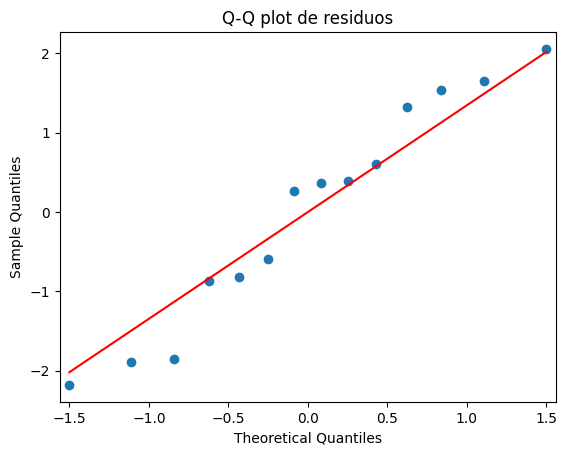

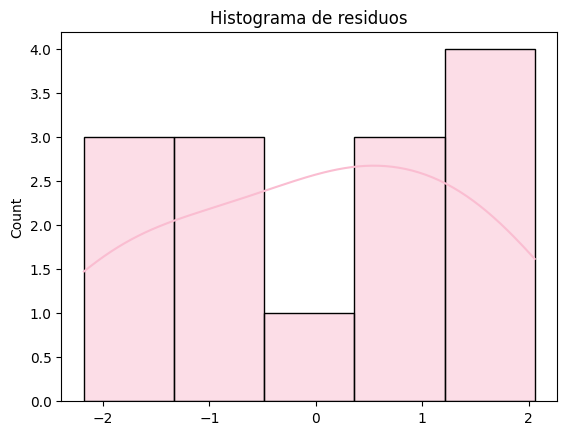

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# n < 30, Shapiro es el más confiable
# n >= 30, Histograma o Q-Q plot

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True, color='#FABDD1')





plt.title("Histograma de residuos")
plt.show()

10. **Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.**

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.8955



11. **Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.**

Si el modelo cumple con todos los supuestos, es confiable para interpolación.

In [ ]:
# mínimo ausencias: 11
# máximo ausencias: 40

# interpolar, valores de x entre 11 y 40

# interpolar
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   7.5135
Para x = 32, y =   5.6808


La extrapolación siempre debe hacerse con cuidado, aunque cumpla con todos los supuestos.

In [ ]:
# mínimo ausencias: 11
# máximo ausencias: 40

# Extrapolar, valores de x que no estén entre 11 y 40

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   11.4407


Con 10 ausencias se espera que el empleado tenga una categoría de salario de 11. Este valor se obtuvo por medio de extrapolación, por lo que se toma con reservas.

12. **Realice una tabla ANOVA e interprete el resultado.**

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Y ~ X
modelo_lineal = ols('''Q('Categoría de salario') ~ Q('Ausencias')''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Q('Ausencias'),1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


Sí hay correlación porque el valor-p de $0.000033$ es menor a un nivel de significancia $\alpha=0.05$.

En los residuales del anova se puede ver la diferencia entre el valor real observado y el valor predicho por el modelo (la media de su respectivo grupo).